## Data Loading

In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

## Data Preprocessing & Feature Engineering Pipeline


## Data Acquisition and Initial Exploration

This allows for an understanding of the available features, data types, and any immediate issues such as missing values or structural inconsistencies.

In [4]:
train_data = pd.read_csv("train.csv")
print("--- Table info ---")
print(train_data.info())
display(train_data.head())

--- Table info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The initial data overview identified gaps in several features, most notably 'Age', 'Cabin', and 'Embarked'. Standard machine learning implementations, such as the Random Forest classifier in Scikit-Learn, are unable to process datasets containing null values (NaNs). To prevent execution errors and ensure the estimator can derive patterns from every available observation, an imputation strategy was integrated directly into the preprocessing function

#### Hypothesis Verification: Gender and Socio-Economic Status

Before proceeding to model training, it is essential to verify fundamental assumptions regarding the features. Historical accounts suggest that survival was strongly correlated with gender ("women and children first") and wealth (represented by passenger class). These simple correlations serve as a baseline for understanding the dataset's predictive structure.

In [5]:
# Add the age groups to see if distribution of survival rate is different in the group of children
train_data['AgeGroup'] = pd.cut(train_data['Age'], [0, 18, 80])
result_table = train_data.pivot_table(
    values='Survived', 
    index=['Sex', 'AgeGroup'], 
    columns='Pclass', 
    observed=False, 
    margins=True, 
    margins_name='Total'
)
display(result_table)
# The age group for model training is not necessary (continious data works better)
train_data.drop('AgeGroup', axis=1, inplace=True)

Pclass                  1         2         3     Total
Sex    AgeGroup                                        
female (0, 18]   0.909091  1.000000  0.511628  0.676471
       (18, 80]  0.972973  0.900000  0.423729  0.782383
male   (0, 18]   0.800000  0.600000  0.215686  0.338028
       (18, 80]  0.375000  0.071429  0.133663  0.180628
Total            0.655914  0.479769  0.239437  0.406162

#### Initial Findings:
* **Gender Bias**: Female passengers show a significantly higher survival rate compared to males, confirming that 'Sex' is likely the most dominant predictive feature.
* **Socio-Economic Impact**: A clear trend is visible where 1st-class passengers had prioritized access to lifeboats, whereas 3rd-class passengers faced the lowest survival probabilities.
* **Priority for Children**: Younger passengers, particularly those under the age of 18, show a statistically higher survival rate across most classes compared to adult males.

#### Hypothesis Verification: Family Dynamics and Group Survival**

Another critical factor to examine is the impact of family size on survival. Traveling with family members could be a double-edged sword: while it might provide a support network (especially for males), large groups might have faced logistical difficulties and emotional distress during the chaotic evacuation process. By analyzing `FamilySize`, we can determine if being part of a group was an advantage or a hindrance.

Survival Statistics by Declared Family Size:
 FamilySize  PassengerCount  SurvivalPercentage
          1             537               30.35
          2             161               55.28
          3             102               57.84
          4              29               72.41
          5              15               20.00
          6              22               13.64
          7              12               33.33
          8               6                0.00
         11               7                0.00


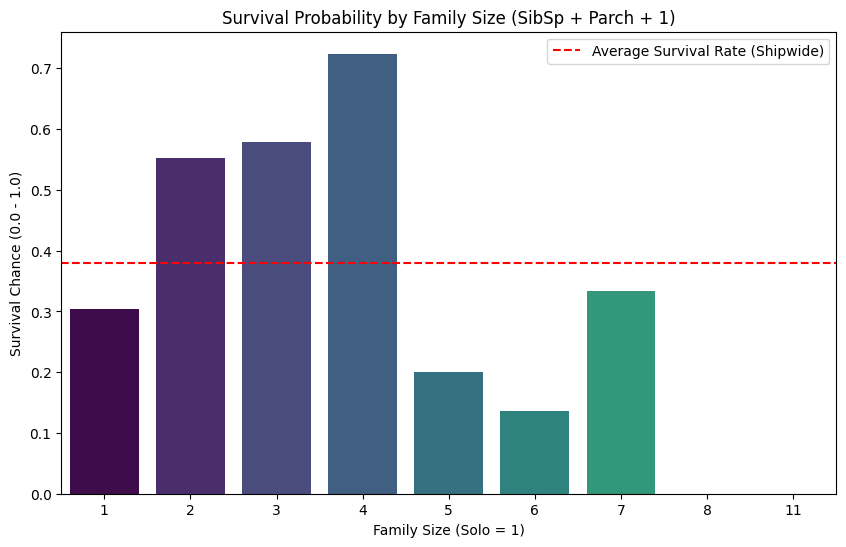

In [6]:
def analyze_family_size(df):
    
    analysis_df = df.copy()  # Prevents modification of the original dataset
    
    # Calculate FamilySize
    analysis_df['FamilySize'] = analysis_df['SibSp'] + analysis_df['Parch'] + 1
    
    # Aggregate statistics: Count of passengers and mean survival rate per group size
    family_stats = analysis_df.groupby('FamilySize')['Survived'].agg(['count', 'mean']).reset_index()
    family_stats.columns = ['FamilySize', 'PassengerCount', 'SurvivalRate']
    family_stats['SurvivalPercentage'] = (family_stats['SurvivalRate'] * 100).round(2)

    return family_stats, analysis_df

# Generate statistics and processed dataframe
stats, processed_df = analyze_family_size(train_data)

print("Survival Statistics by Declared Family Size:")
print(stats[['FamilySize', 'PassengerCount', 'SurvivalPercentage']].to_string(index=False))

# Visualization of survival rates relative to the ship's average
plt.figure(figsize=(10, 6))
sns.barplot(x='FamilySize', y='SurvivalRate', data=stats, hue='FamilySize', palette='viridis', legend=False)

# Reference line representing the overall average survival rate as a cut-off (~38%)
plt.axhline(0.38, color='red', linestyle='--', label='Average Survival Rate (Shipwide)') 

plt.title("Survival Probability by Family Size (SibSp + Parch + 1)")
plt.ylabel("Survival Chance (0.0 - 1.0)")
plt.xlabel("Family Size (Solo = 1)")
plt.legend()
plt.show()

The relationship between family size and survival is not straightforward. While a general trend favors small families, there are nuances that require careful interpretation:

* **Statistical Noise in Large Groups**: A survival peak is observed for families of 7. However, it is crucial to note that the sample size for large families (5, 6, 7+ members) is significantly smaller. The survival of even a few individuals in these groups leads to a disproportionately high survival percentage, which may not represent a reliable trend.
* **Non-Linear Correlation**: The data suggests a non-linear relationship. Since standard heatmaps typically utilize the **Pearson Correlation Coefficient**, which measures linear strength, this specific dynamic might appear weak or stay hidden in a correlation matrix.